### This notebook chooses and then saves the anchor frames to use from the full observation to build the structure from motion maps

In [1]:
import os

import cv2
from dotenv import load_dotenv

from koger_detection.landscape.drone_movement import get_anchor_frames_without_log

In [2]:
load_dotenv()

video_name = "DJI_20251031163737_0001_W"
# video_name = "bear_big2a_2023_08_16_koger_01_05_DJI_20230816175814_0573_D"
video_folder = os.path.join(os.environ.get("PROJECT_ROOT"), "media")
video_file = os.path.join(video_folder, video_name + ".MP4")

if os.path.exists(video_file):
    print(f"video exists")

out_folder = os.path.join(os.environ.get("PROJECT_ROOT"), video_name, "anchor-images")
os.makedirs(out_folder, exist_ok=True)

video exists


### A new anchor frame is choosen whenever the number of tracked local features in a frame drops below 100

In [3]:
anchor_info, final_warps = get_anchor_frames_without_log(video_file, out_folder, 
                                                         video_name, inlier_threshold=60,
                                                         max_pseudo_anchors=1,
                                                         ransac_reproj_threshold=5)

0 frames processed.  0 anchors saved.
2000 frames processed.  2 anchors saved.
4000 frames processed.  3 anchors saved.
6000 frames processed.  22 anchors saved.
8000 frames processed.  37 anchors saved.
10000 frames processed.  45 anchors saved.
12000 frames processed.  48 anchors saved.
14000 frames processed.  92 anchors saved.
16000 frames processed.  108 anchors saved.
18000 frames processed.  165 anchors saved.
20000 frames processed.  168 anchors saved.
22000 frames processed.  169 anchors saved.
24000 frames processed.  169 anchors saved.
26000 frames processed.  170 anchors saved.
28000 frames processed.  171 anchors saved.
Empty frame. Ending stream.


In [19]:
# # Save anchor frames for structure from motion processing
anchor_info.to_csv(os.path.join(out_folder, "anchor_frame_info.csv"), index=False)

### Use below code to check quality of warps between anchor frames (these warps are just for checking, won't be used elsewhere in method)

Text(0.5, 1.0, 'Frame 1 raw')

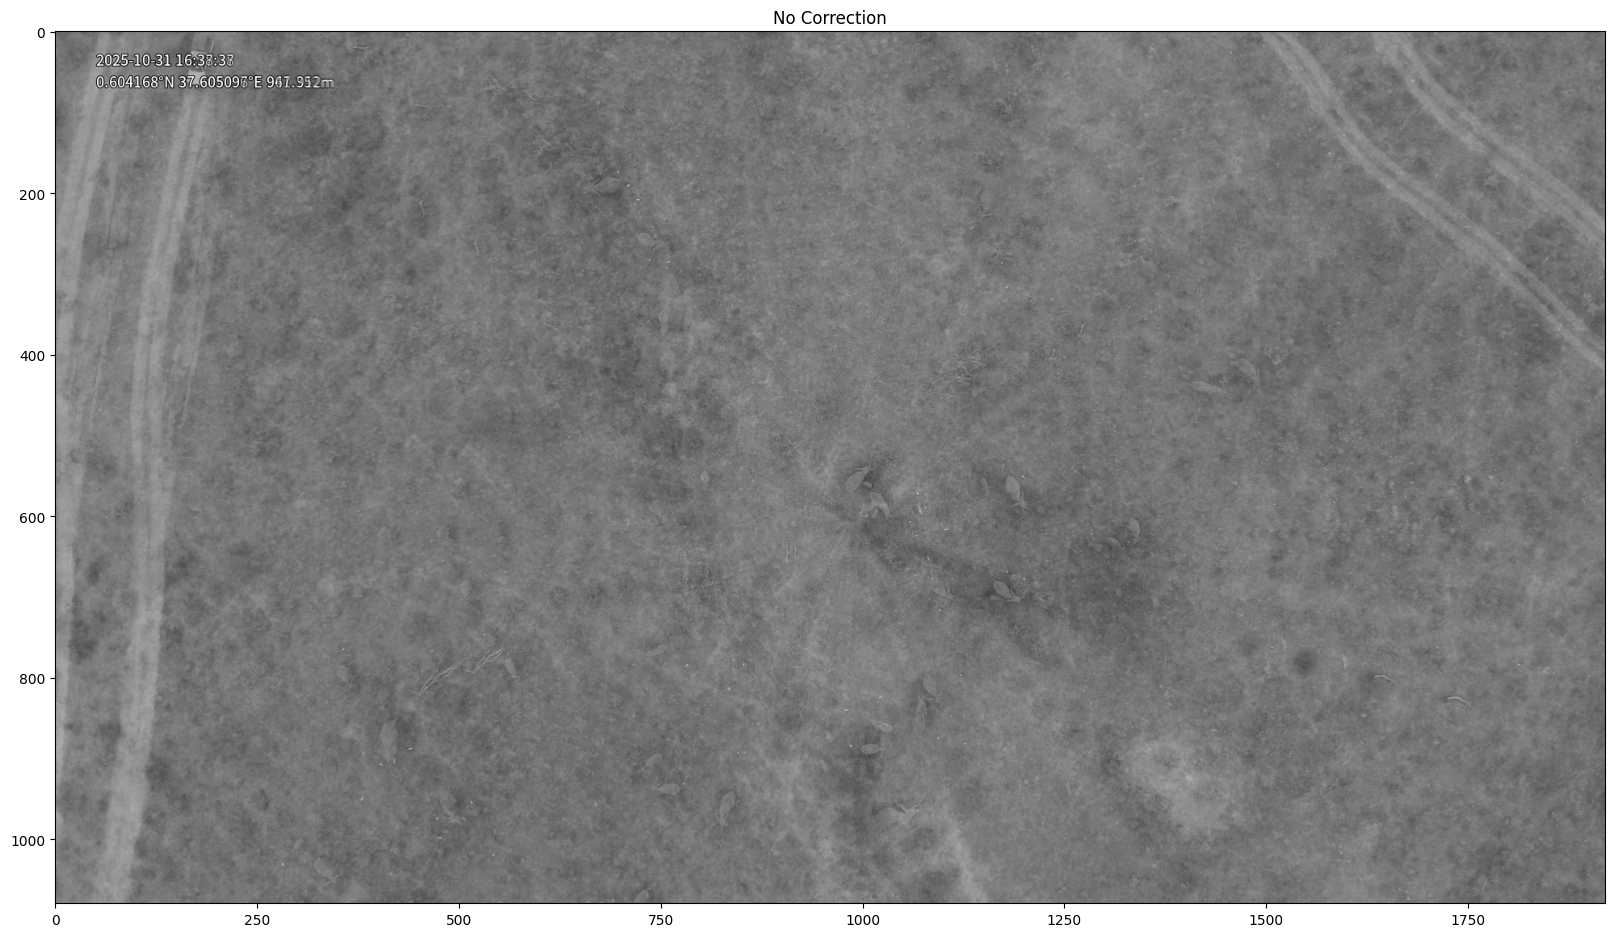

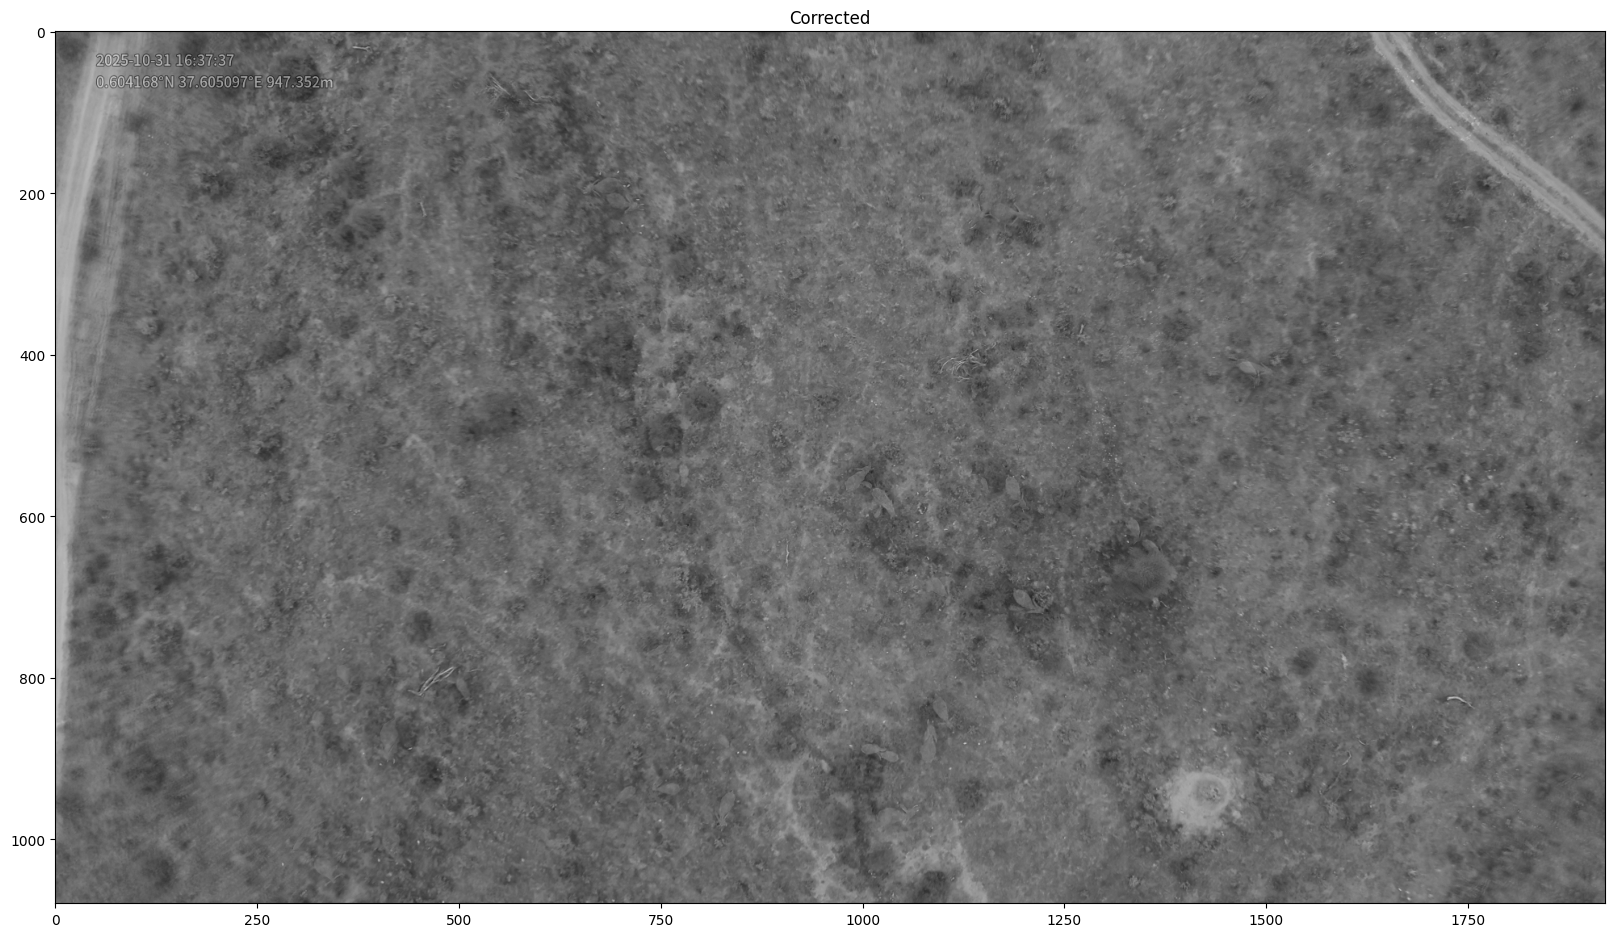

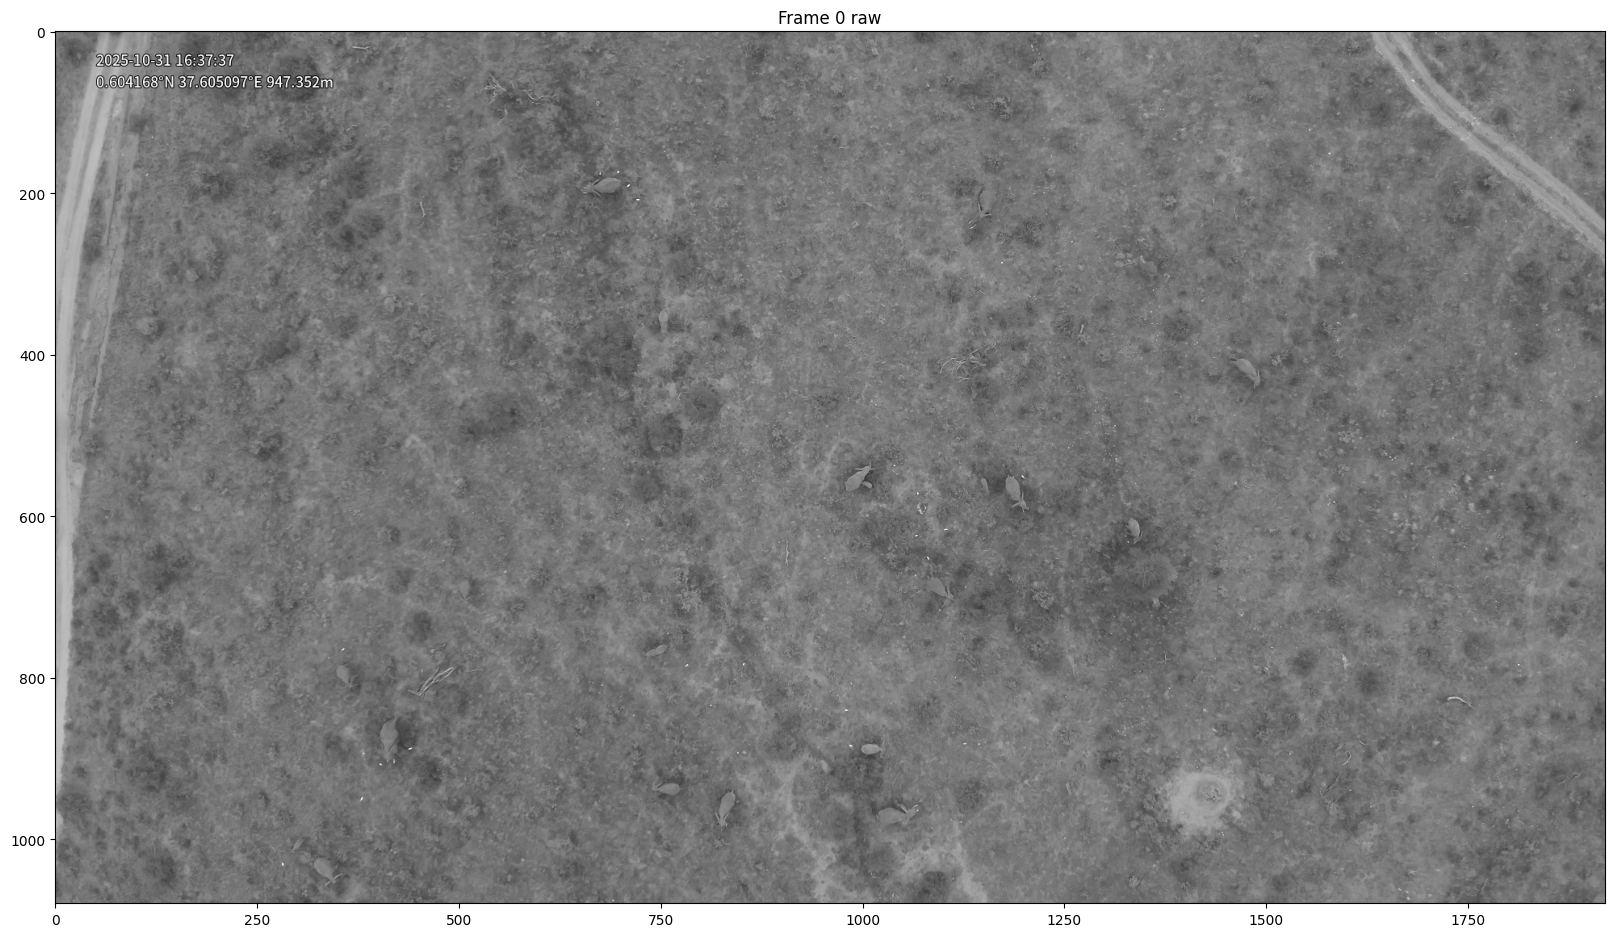

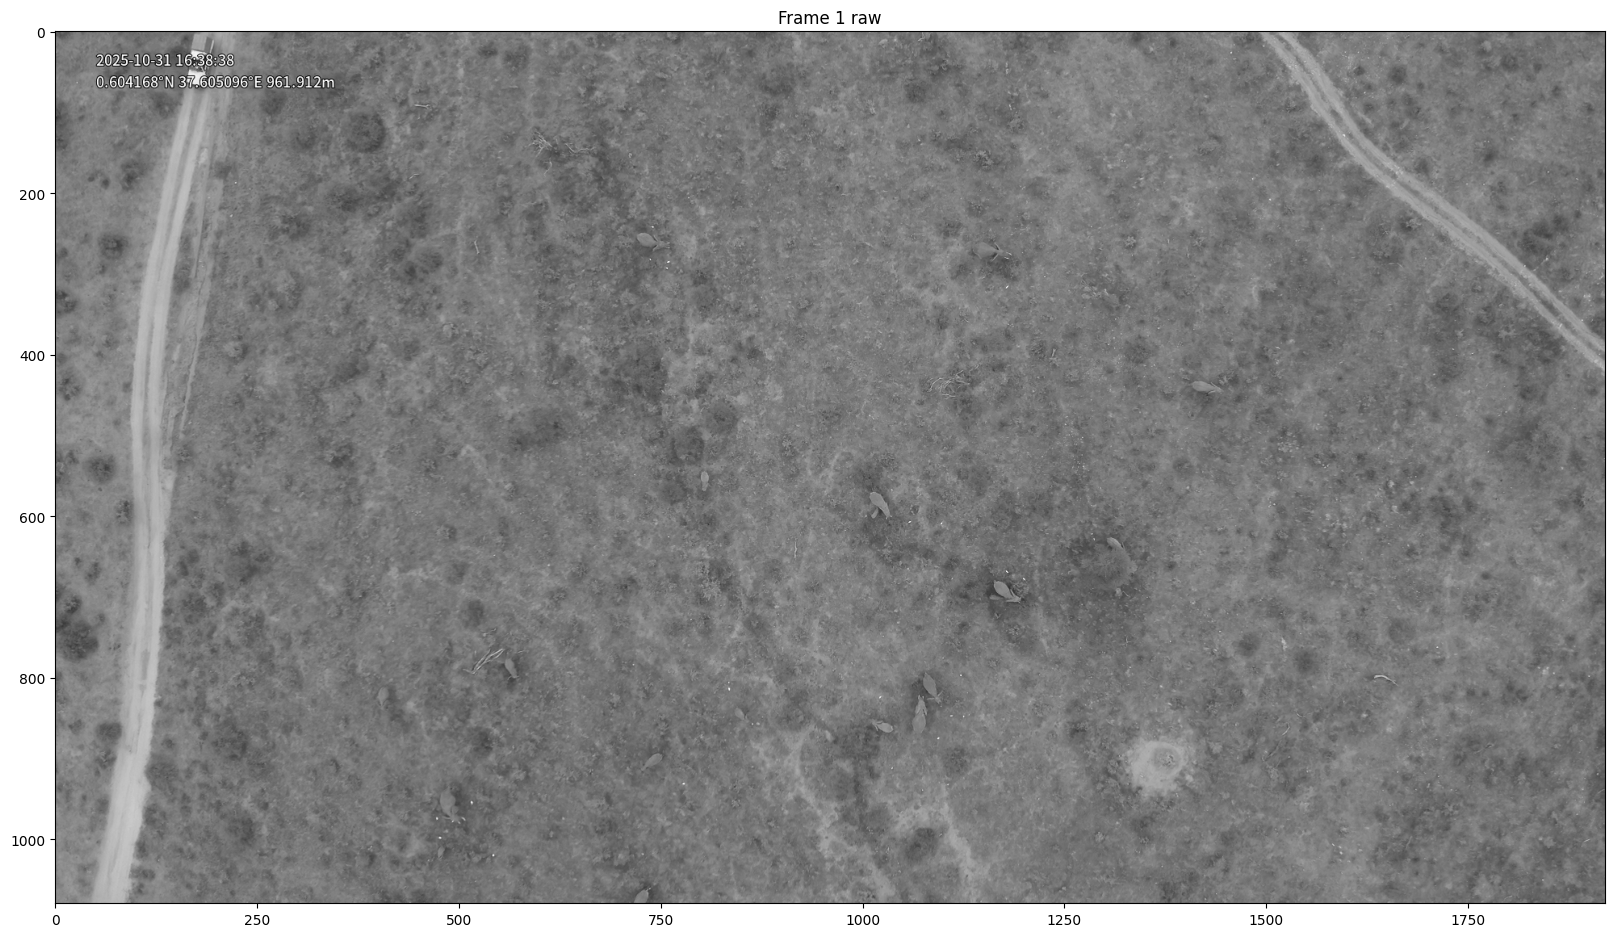

In [4]:
import matplotlib.pyplot as plt
a_ind = 0

anchor_files = [f for f in list(anchor_info['filename'])]

frame0_raw = cv2.imread(anchor_files[a_ind])
frame0_gray = cv2.cvtColor(frame0_raw, cv2.COLOR_BGR2GRAY)

frame1_raw = cv2.imread(anchor_files[a_ind+1])
frame1_gray = cv2.cvtColor(frame1_raw, cv2.COLOR_BGR2GRAY)

warp = final_warps[a_ind]

warped_image = cv2.warpAffine(frame1_gray, M=warp[:2], 
                              dsize=(frame0_raw.shape[1], frame0_raw.shape[0]))

plt.figure(figsize=(20,20))
plt.imshow(frame0_gray, cmap='gray', )
plt.imshow(frame1_gray, alpha=.5, cmap='gray')
plt.title("No Correction")

plt.figure(figsize=(20,20))
plt.imshow(frame0_gray, cmap='gray', )
plt.imshow(warped_image, alpha=.5, cmap='gray')
plt.title("Corrected")

plt.figure(figsize=(20,20))
plt.imshow(frame0_gray, cmap='gray', )
plt.title("Frame 0 raw")
plt.figure(figsize=(20,20))
plt.imshow(frame1_gray, alpha=1.0, cmap='gray')
plt.title("Frame 1 raw")